<a href="https://colab.research.google.com/github/rachakondasaivarshini/GAN-PROGRAMS/blob/main/GAn_EXP7_postlab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

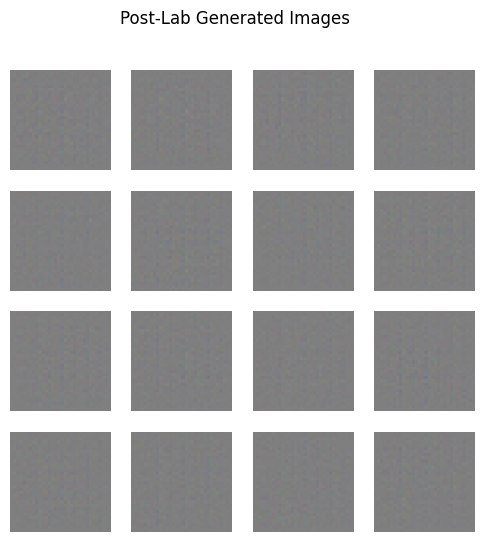

Post-Lab completed successfully.
Generator model saved.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 - all 10 classes
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
y_train = y_train.flatten()

x_train = (x_train.astype("float32") - 127.5) / 127.5

# Data augmentation
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
])

# Generator
def generator():
    return tf.keras.Sequential([
        layers.Input((100,)),
        layers.Dense(4*4*128),
        layers.Reshape((4,4,128)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(128,4,2,"same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(64,4,2,"same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(3,4,2,"same",activation="tanh")
    ])

G = generator()

# Generate images
noise = tf.random.normal([16,100])
images = G(noise, training=False)
images = (images + 1) / 2

# Display
plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.suptitle("Post-Lab Generated Images")
plt.show()

# Save model
G.save("postlab_generator.keras")

print("Post-Lab completed successfully.")
print("Generator model saved.")